 Bước (k)  |    x^(k)     |  f'(x^(k))   |   f(x^(k))  
    0      |    5.0000    |    6.0000    |  10.000000  
    1      |    3.8000    |    3.6000    |   4.240000  
    2      |    3.0800    |    2.1600    |   2.166400  
    3      |    2.6480    |    1.2960    |   1.419904  
    4      |    2.3888    |    0.7776    |   1.151165  


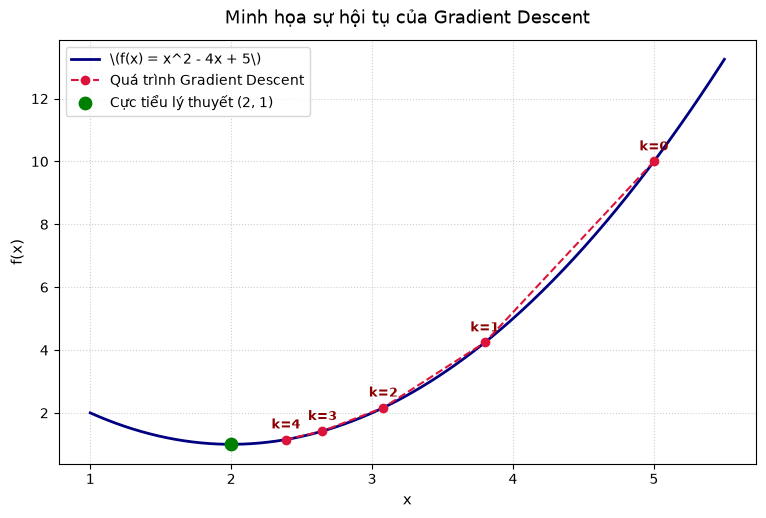

In [ ]:
# %%
import matplotlib.pyplot as plt
import numpy as np


# 1. Định nghĩa hàm số và đạo hàm
def f(x):
  return x**2 - 4 * x + 5


def df(x):
  return 2 * x - 4


# Khai báo các tham số ban đầu
x_0 = 5.0
learning_rate = 0.2
steps = 4

# Khởi tạo danh sách lưu trữ lịch sử
history_k = [0]
history_x = [x_0]
history_df = [df(x_0)]
history_f = [f(x_0)]

# 2 & 3. Thực hiện 4 bước cập nhật Gradient Descent
x_current = x_0
for k in range(1, steps + 1):
  x_next = x_current - learning_rate * df(x_current)

  history_k.append(k)
  history_x.append(x_next)
  history_df.append(df(x_next))
  history_f.append(f(x_next))

  x_current = x_next

# In bảng kết quả dạng text
print('=' * 55)
print(f"{'Bước (k)':^10} | {'x^(k)':^12} | {'f\'(x^(k))':^12} | {'f(x^(k))':^12}")
print('=' * 55)

for k, x_val, df_val, f_val in zip(
    history_k, history_x, history_df, history_f
):
  print(f'{k:^10} | {x_val:^12.4f} | {df_val:^12.4f} | {f_val:^12.6f}')

print('=' * 55)

# %%
# 4. Trực quan hóa sự hội tụ bằng Đồ thị
x_vals = np.linspace(1.0, 5.5, 300)
y_vals = f(x_vals)

plt.figure(figsize=(9, 5.5))
plt.plot(x_vals, y_vals, label=r'\(f(x) = x^2 - 4x + 5\)', color='navy', lw=2)
plt.plot(
    history_x,
    history_f,
    color='crimson',
    marker='o',
    linestyle='--',
    linewidth=1.5,
    markersize=6,
    label='Quá trình Gradient Descent',
)

for k, x_val, f_val in zip(history_k, history_x, history_f):
  plt.annotate(
      f'k={k}',
      (x_val, f_val),
      textcoords='offset points',
      xytext=(0, 8),
      ha='center',
      fontsize=9,
      weight='bold',
      color='darkred',
  )

plt.scatter(
    [2], [1], color='green', s=80, zorder=5, label='Cực tiểu lý thuyết (2, 1)'
)
plt.title('Minh họa sự hội tụ của Gradient Descent', fontsize=13, pad=12)
plt.xlabel('x', fontsize=11)
plt.ylabel('f(x)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.show()